# Male Age Model Training (LDAE, Improved)

Male-specific age model using pre-encoded LDAE labels with age-aware sample weighting and 3-stage fine-tuning.


In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_DIR = Path("/content/data")
    CHECKPOINT_DIR = Path("/content/checkpoints/male_age_model")
else:
    NOTEBOOK_DIR = Path(".").resolve()
    PROJECT_ROOT = NOTEBOOK_DIR.parent
    DATA_DIR = PROJECT_ROOT / "data"
    CHECKPOINT_DIR = PROJECT_ROOT / "models" / "male_age_model"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

IMAGES_DIR = DATA_DIR / "utk_face"
TRAIN_AGE_MALE_CSV = DATA_DIR / "splits" / "train_age_male.csv"
TRAIN_AGE_FEMALE_CSV = DATA_DIR / "splits" / "train_age_female.csv"
VAL_AGE_MALE_CSV = DATA_DIR / "splits" / "val_age_male.csv"
VAL_AGE_FEMALE_CSV = DATA_DIR / "splits" / "val_age_female.csv"
TEST_CSV = DATA_DIR / "splits" / "test.csv"

BEST_MODEL = CHECKPOINT_DIR / "best_male_age_model.keras"

print(f"Running in Colab: {IN_COLAB}")
print(f"Data dir        : {DATA_DIR}")
print(f"Images dir      : {IMAGES_DIR}")
print(f"Checkpoint dir  : {CHECKPOINT_DIR}")


Running in Colab: True
Data dir        : /content/data
Images dir      : /content/data/utk_face
Checkpoint dir  : /content/checkpoints/male_age_model


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {tf.config.list_physical_devices('GPU')}")

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 15
EPOCHS_STAGE3 = 15
LR_STAGE1 = 1e-3
LR_STAGE2 = 1e-5
LR_STAGE3 = 5e-6
DROPOUT_RATE = 0.3
DENSE_UNITS = 256
NUM_AGE_BINS = 117
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)


TensorFlow version : 2.19.0
GPUs available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
def parse_age_distribution(dist_str: str) -> np.ndarray:
    values = np.fromstring(dist_str, sep=",", dtype=np.float32)
    if values.size != NUM_AGE_BINS:
        raise ValueError(
            f"Expected {NUM_AGE_BINS} LDAE bins, got {values.size}."
        )

    total = float(values.sum())
    if total <= 0:
        raise ValueError("Invalid LDAE distribution with non-positive sum.")

    return values / total


def load_age_dataframe(
    csv_path: Path,
) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["filepath"] = df["filename"].apply(
        lambda fname: str(IMAGES_DIR / fname)
    )
    df["age_distribution_arr"] = df["age_distribution"].apply(
        parse_age_distribution
    )
    return df[["filepath", "age", "gender_id", "age_distribution_arr"]]


train_df = load_age_dataframe(TRAIN_AGE_MALE_CSV)
val_df = load_age_dataframe(VAL_AGE_MALE_CSV)

test_df = load_age_dataframe(TEST_CSV)
test_df = test_df[test_df["gender_id"] == 0].reset_index(drop=True)

print(f"Train samples: {len(train_df)}")
print(f"Val samples  : {len(val_df)}")
print(f"Test samples : {len(test_df)}")

train_age = train_df["age"].astype(int).to_numpy()
age_counts = np.bincount(train_age, minlength=NUM_AGE_BINS)
age_weights = np.zeros(NUM_AGE_BINS, dtype=np.float32)

nonzero = age_counts > 0
age_weights[nonzero] = 1.0 / np.sqrt(age_counts[nonzero].astype(np.float32))
age_weights[nonzero] /= age_weights[nonzero].mean()

train_df = train_df.copy()
train_df["sample_weight"] = train_df["age"].astype(int).map(
    lambda a: float(age_weights[a])
)

print(
    f"Sample-weight range: "
    f"{train_df['sample_weight'].min():.4f} to "
    f"{train_df['sample_weight'].max():.4f}"
)


Train samples: 7373
Val samples  : 3159
Test samples : 1859
Sample-weight range: 0.1813 to 4.3958


In [4]:
AUTOTUNE = tf.data.AUTOTUNE


def parse_image(
    filepath: tf.Tensor,
    dist: tf.Tensor,
    sw: tf.Tensor,
):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = preprocess_input(image)
    return image, dist, sw


def augment(
    image: tf.Tensor,
    dist: tf.Tensor,
    sw: tf.Tensor,
):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    return image, dist, sw


def make_dataset(
    df: pd.DataFrame,
    training: bool = False,
    use_weights: bool = False,
) -> tf.data.Dataset:
    filepaths = df["filepath"].to_numpy()
    dists = np.stack(df["age_distribution_arr"].to_numpy()).astype(np.float32)

    if use_weights:
        sample_weights = df["sample_weight"].to_numpy(dtype=np.float32)
    else:
        sample_weights = np.ones(len(df), dtype=np.float32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, dists, sample_weights))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    if use_weights:
        ds = ds.map(
            lambda x, y, w: (x, y, w),
            num_parallel_calls=AUTOTUNE,
        )
    else:
        ds = ds.map(
            lambda x, y, w: (x, y),
            num_parallel_calls=AUTOTUNE,
        )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


val_df = val_df.copy()
val_df["sample_weight"] = 1.0

test_df = test_df.copy()
test_df["sample_weight"] = 1.0

train_ds = make_dataset(train_df, training=True, use_weights=True)
val_ds = make_dataset(val_df, training=False, use_weights=False)
test_ds = make_dataset(test_df, training=False, use_weights=False)

print("Datasets built successfully.")


Datasets built successfully.


In [5]:
class ExpectedAgeMAE(keras.metrics.Metric):
    def __init__(
        self,
        name: str = "expected_age_mae",
        **kwargs,
    ):
        super().__init__(name=name, **kwargs)
        self.total_abs_error = self.add_weight(
            name="total_abs_error",
            initializer="zeros",
        )
        self.count = self.add_weight(
            name="count",
            initializer="zeros",
        )
        self.age_bins = tf.cast(tf.range(NUM_AGE_BINS), tf.float32)

    def update_state(
        self,
        y_true,
        y_pred,
        sample_weight=None,
    ):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        true_age = tf.reduce_sum(y_true * self.age_bins, axis=-1)
        pred_age = tf.reduce_sum(y_pred * self.age_bins, axis=-1)
        abs_err = tf.abs(true_age - pred_age)

        if sample_weight is not None:
            sample_weight = tf.cast(sample_weight, tf.float32)
            abs_err = abs_err * sample_weight
            batch_count = tf.reduce_sum(sample_weight)
        else:
            batch_count = tf.cast(tf.size(abs_err), tf.float32)

        self.total_abs_error.assign_add(tf.reduce_sum(abs_err))
        self.count.assign_add(batch_count)

    def result(self):
        return tf.math.divide_no_nan(self.total_abs_error, self.count)

    def reset_state(self):
        self.total_abs_error.assign(0.0)
        self.count.assign(0.0)


def build_model(
    learning_rate: float,
    model_name: str,
) -> keras.Model:
    backbone = ResNet50(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMAGE_SIZE, 3),
        name="resnet50",
    )
    backbone.trainable = False

    inputs = keras.Input(shape=(*IMAGE_SIZE, 3), name="image_input")
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(DENSE_UNITS, activation="relu", name="fc1")(x)
    x = layers.Dropout(DROPOUT_RATE, name="dropout")(x)
    outputs = layers.Dense(
        NUM_AGE_BINS,
        activation="softmax",
        name="age_distribution_output",
    )(x)

    model = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.KLDivergence(),
        metrics=[ExpectedAgeMAE()],
    )
    return model


def freeze_backbone_except(
    backbone: keras.Model,
    trainable_prefixes: tuple[str, ...],
) -> None:
    backbone.trainable = True
    for layer in backbone.layers:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in trainable_prefixes
        )
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False


def make_callbacks(
    stage_name: str,
    patience: int = 5,
):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(BEST_MODEL),
            monitor="val_expected_age_mae",
            mode="min",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_expected_age_mae",
            mode="min",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            str(CHECKPOINT_DIR / f"{stage_name}_history.csv"),
            append=False,
        ),
    ]


if BEST_MODEL.exists():
    model = keras.models.load_model(
        str(BEST_MODEL),
        custom_objects={"ExpectedAgeMAE": ExpectedAgeMAE},
    )
    print(f"Resumed from checkpoint: {BEST_MODEL}")
else:
    model = build_model(
        learning_rate=LR_STAGE1,
        model_name="male_age_model",
    )
    print("No checkpoint found, starting from scratch.")

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
No checkpoint found, starting from scratch.


Model: "male_age_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ age_distribution_output (Dense) │ (None, 117)            │        30,069 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,142,325 (92.10 MB)

 Trainable params: 554,613 (2.12 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [6]:
# Stage 1: train head with frozen backbone
if not BEST_MODEL.exists():
    model = build_model(
        learning_rate=LR_STAGE1,
        model_name="male_age_model",
    )
else:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE1),
        loss=keras.losses.KLDivergence(),
        metrics=[ExpectedAgeMAE()],
    )

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=make_callbacks("stage1"),
)


Epoch 1/20
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - expected_age_mae: 14.2127 - loss: 0.7946
Epoch 1: val_expected_age_mae improved from inf to 7.69531, saving model to /content/checkpoints/male_age_model/best_male_age_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 61s 201ms/step - expected_age_mae: 14.1980 - loss: 0.7941 - val_expected_age_mae: 7.6953 - val_loss: 1.1199 - learning_rate: 0.0010
Epoch 2/20
230/231 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - expected_age_mae: 8.0418 - loss: 0.5382
Epoch 2: val_expected_age_mae improved from 7.69531 to 7.22510, saving model to /content/checkpoints/male_age_model/best_male_age_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 33s 144ms/step - expected_age_mae: 8.0397 - loss: 0.5382 - val_expected_age_mae: 7.2251 - val_loss: 1.0828 - learning_rate: 0.0010
Epoch 3/20
230/231 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - expected_age_mae: 7.4554 - loss: 0.4971
Epoch 3: val_expected_age_mae improved from 7.22510 to 7.08704, saving model to /content/checkpoints/male_age_m

In [7]:
# Stage 2: fine-tune conv5
model = keras.models.load_model(
    str(BEST_MODEL),
    custom_objects={"ExpectedAgeMAE": ExpectedAgeMAE},
)

backbone = model.get_layer("resnet50")
freeze_backbone_except(
    backbone,
    trainable_prefixes=("conv5",),
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE2),
    loss=keras.losses.KLDivergence(),
    metrics=[ExpectedAgeMAE()],
)

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=make_callbacks("stage2"),
)


Epoch 1/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - expected_age_mae: 6.0090 - loss: 0.3818
Epoch 1: val_expected_age_mae improved from inf to 6.29735, saving model to /content/checkpoints/male_age_model/best_male_age_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 73s 244ms/step - expected_age_mae: 6.0091 - loss: 0.3818 - val_expected_age_mae: 6.2974 - val_loss: 0.9470 - learning_rate: 1.0000e-05
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - expected_age_mae: 5.4652 - loss: 0.3593
Epoch 2: val_expected_age_mae did not improve from 6.29735
231/231 ━━━━━━━━━━━━━━━━━━━━ 42s 180ms/step - expected_age_mae: 5.4653 - loss: 0.3593 - val_expected_age_mae: 6.3544 - val_loss: 0.9640 - learning_rate: 1.0000e-05
Epoch 3/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - expected_age_mae: 5.2726 - loss: 0.3329
Epoch 3: val_expected_age_mae did not improve from 6.29735
231/231 ━━━━━━━━━━━━━━━━━━━━ 41s 179ms/step - expected_age_mae: 5.2727 - loss: 0.3329 - val_expected_age_mae: 6.4232 - val_loss:

In [8]:
# Stage 3: fine-tune conv4 + conv5
model = keras.models.load_model(
    str(BEST_MODEL),
    custom_objects={"ExpectedAgeMAE": ExpectedAgeMAE},
)

backbone = model.get_layer("resnet50")
freeze_backbone_except(
    backbone,
    trainable_prefixes=("conv4", "conv5"),
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_STAGE3),
    loss=keras.losses.KLDivergence(),
    metrics=[ExpectedAgeMAE()],
)

history_stage3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE3,
    callbacks=make_callbacks("stage3"),
)

print(f"Training complete. Best model saved to: {BEST_MODEL}")


Epoch 1/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - expected_age_mae: 4.1931 - loss: 0.2655
Epoch 1: val_expected_age_mae improved from inf to 5.99005, saving model to /content/checkpoints/male_age_model/best_male_age_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 94s 318ms/step - expected_age_mae: 4.1934 - loss: 0.2655 - val_expected_age_mae: 5.9901 - val_loss: 0.9669 - learning_rate: 5.0000e-06
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - expected_age_mae: 3.9532 - loss: 0.2550
Epoch 2: val_expected_age_mae improved from 5.99005 to 5.90963, saving model to /content/checkpoints/male_age_model/best_male_age_model.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 59s 255ms/step - expected_age_mae: 3.9535 - loss: 0.2550 - val_expected_age_mae: 5.9096 - val_loss: 0.9631 - learning_rate: 5.0000e-06
Epoch 3/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - expected_age_mae: 3.7765 - loss: 0.2380
Epoch 3: val_expected_age_mae did not improve from 5.90963
231/231 ━━━━━━━━━━━━━━━━━━━━ 56s 241ms/step -

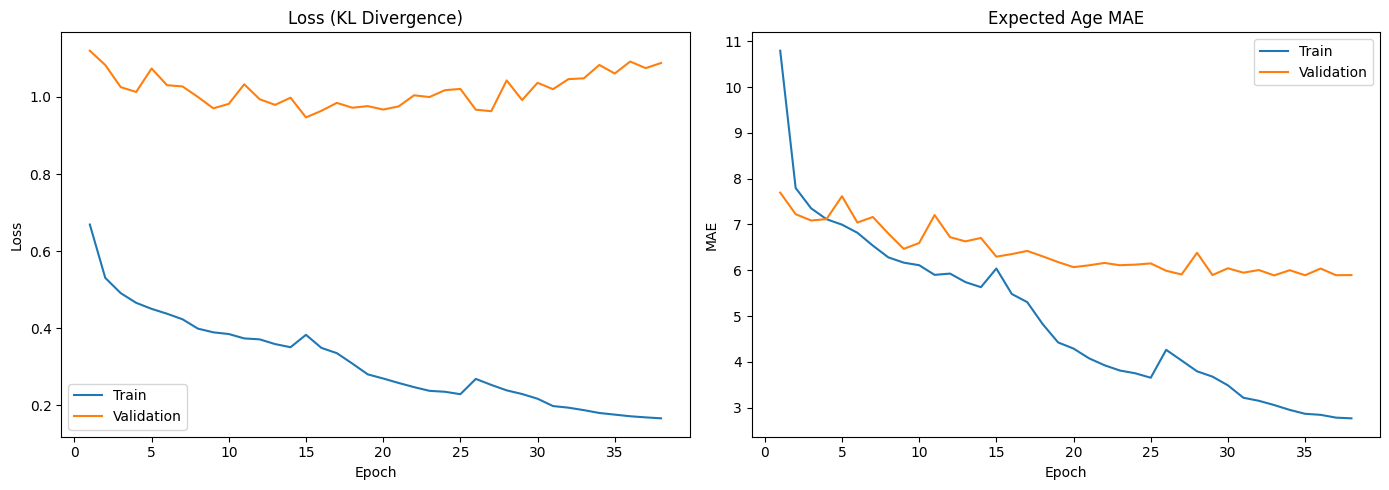

In [9]:
def _concat_metric(
    histories,
    key: str,
):
    values = []
    for h in histories:
        values.extend(h.history.get(key, []))
    return values


all_histories = [history_stage1, history_stage2, history_stage3]
train_loss = _concat_metric(all_histories, "loss")
val_loss = _concat_metric(all_histories, "val_loss")
train_mae = _concat_metric(all_histories, "expected_age_mae")
val_mae = _concat_metric(all_histories, "val_expected_age_mae")

epoch_axis = np.arange(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epoch_axis, train_loss, label="Train")
axes[0].plot(epoch_axis, val_loss, label="Validation")
axes[0].set_title("Loss (KL Divergence)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(epoch_axis, train_mae, label="Train")
axes[1].plot(epoch_axis, val_mae, label="Validation")
axes[1].set_title("Expected Age MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.show()


In [10]:
best_model = keras.models.load_model(
    str(BEST_MODEL),
    custom_objects={"ExpectedAgeMAE": ExpectedAgeMAE},
)

eval_metrics = best_model.evaluate(test_ds, verbose=1)
print("\nTest metrics:")
for name, value in zip(best_model.metrics_names, eval_metrics):
    print(f"{name}: {value:.6f}")

age_bins = np.arange(NUM_AGE_BINS, dtype=np.float32)
pred_dist = best_model.predict(test_ds, verbose=1)
pred_age = (pred_dist * age_bins[None, :]).sum(axis=1)
true_age = test_df["age"].to_numpy(dtype=np.float32)
manual_mae = np.mean(np.abs(pred_age - true_age))
print(f"Manual decoded-age MAE: {manual_mae:.4f}")


59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 144ms/step - expected_age_mae: 6.1253 - loss: 1.0735

Test metrics:
loss: 1.067984
compile_metrics: 5.985243
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step
Manual decoded-age MAE: 5.9922


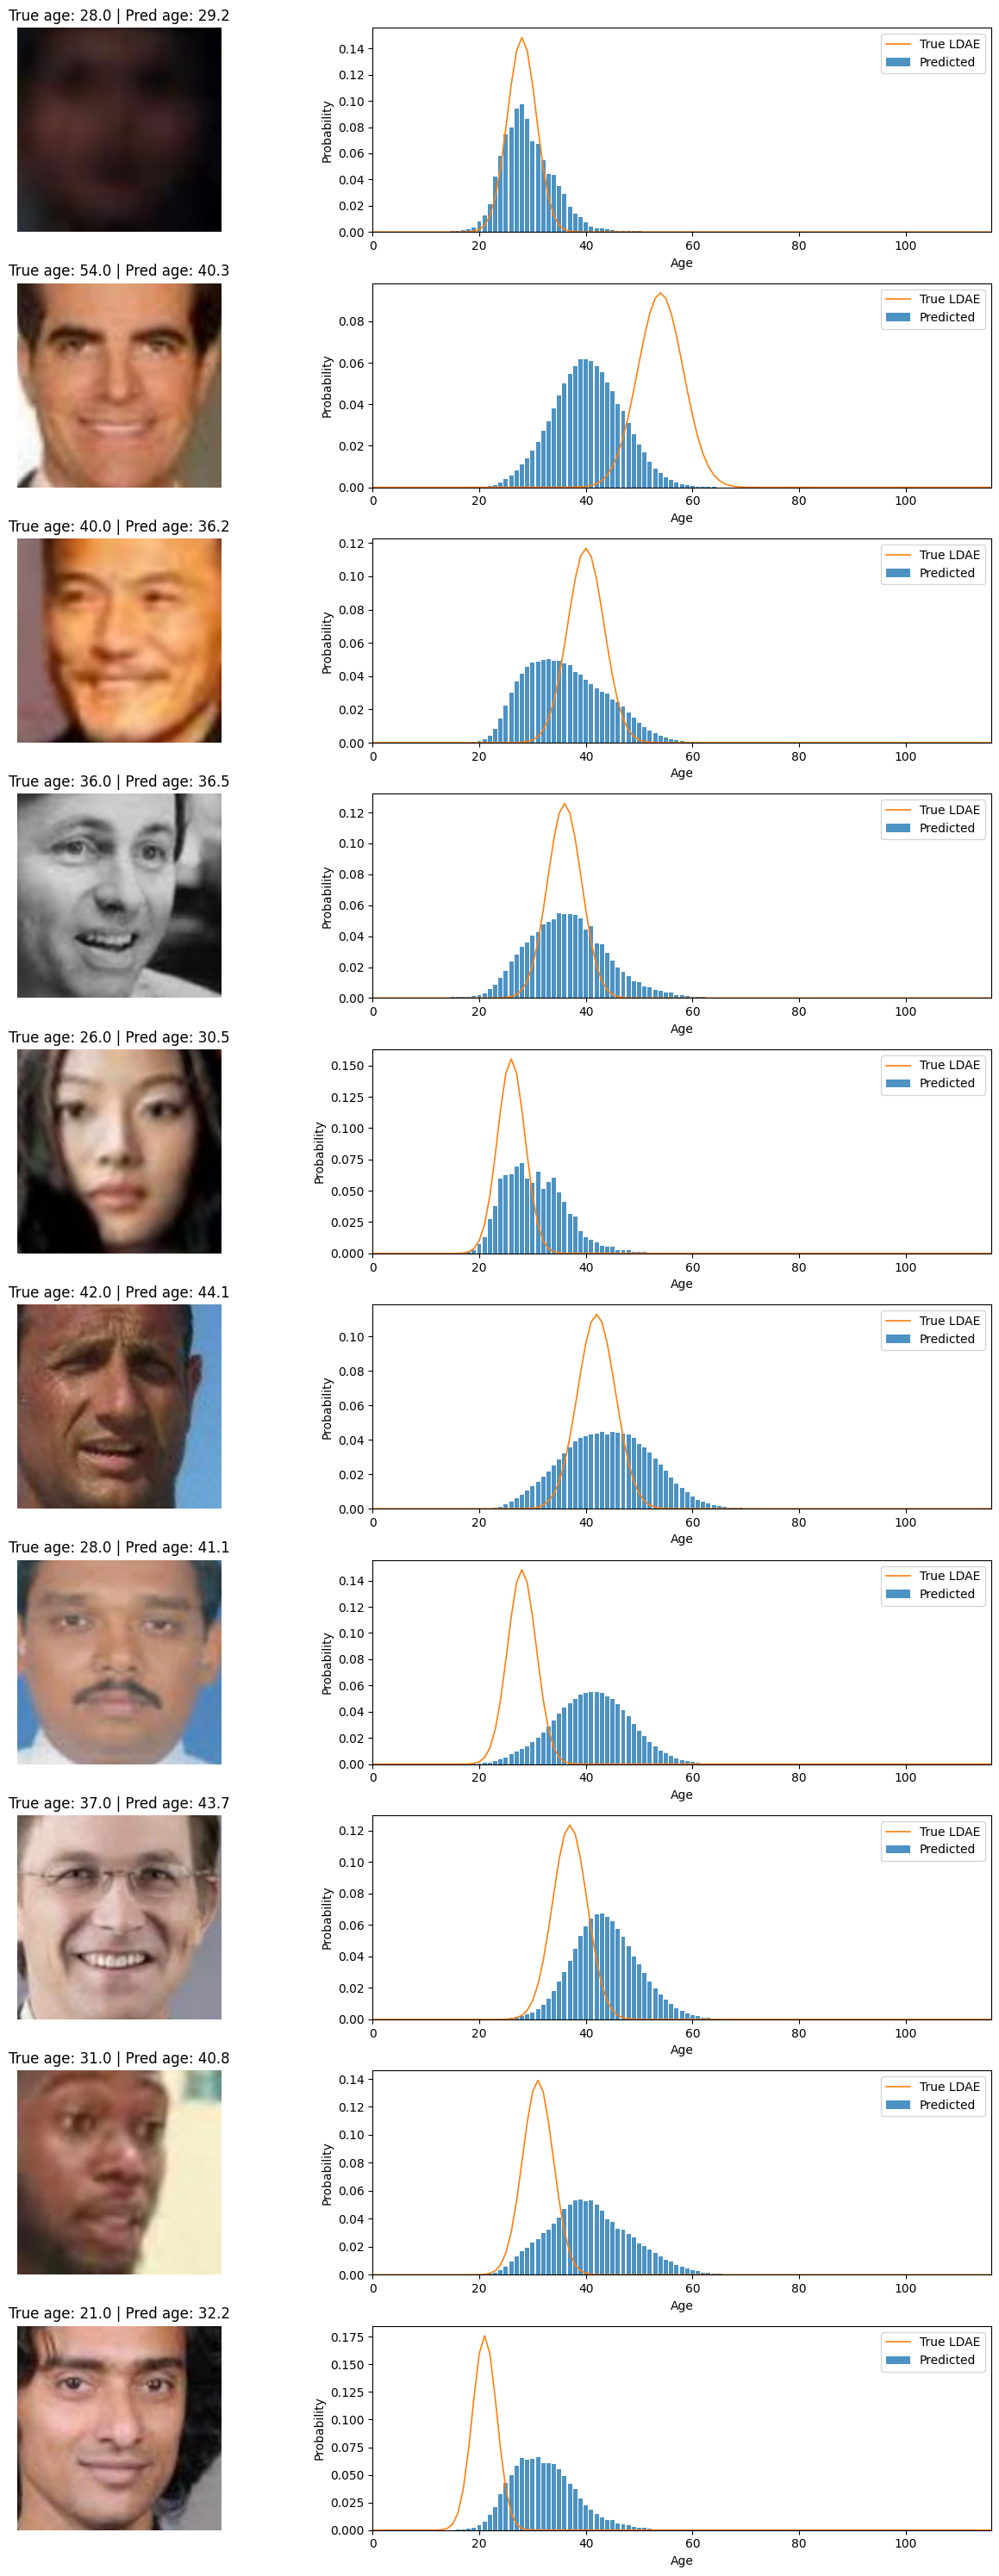

In [11]:
def load_display_image(
    filepath: str,
) -> np.ndarray:
    img = PILImage.open(filepath).convert("RGB").resize(IMAGE_SIZE)
    return np.array(img)


def preprocess_for_model(
    filepath: str,
) -> np.ndarray:
    img = load_display_image(filepath).astype(np.float32)
    img = preprocess_input(img)
    return img


def show_sample_predictions(
    model: keras.Model,
    df: pd.DataFrame,
    n_samples: int = 10,
    seed: int = 42,
) -> None:
    if len(df) < n_samples:
        n_samples = len(df)

    sample_df = df.sample(n=n_samples, random_state=seed).reset_index(drop=True)
    age_bins = np.arange(NUM_AGE_BINS)

    fig, axes = plt.subplots(n_samples, 2, figsize=(14, 3 * n_samples))
    if n_samples == 1:
        axes = np.array([axes])

    for i in range(n_samples):
        path = sample_df.loc[i, "filepath"]
        true_age = float(sample_df.loc[i, "age"])
        true_dist = np.array(sample_df.loc[i, "age_distribution_arr"], dtype=np.float32)

        x = preprocess_for_model(path)
        pred = model.predict(np.expand_dims(x, axis=0), verbose=0)[0]
        pred_age = float(np.sum(pred * age_bins))

        ax_img = axes[i, 0]
        ax_bar = axes[i, 1]

        ax_img.imshow(load_display_image(path))
        ax_img.axis("off")
        ax_img.set_title(f"True age: {true_age:.1f} | Pred age: {pred_age:.1f}")

        ax_bar.bar(
            age_bins,
            pred,
            alpha=0.8,
            label="Predicted",
            color="#1f77b4",
        )
        ax_bar.plot(
            age_bins,
            true_dist,
            label="True LDAE",
            color="#ff7f0e",
            linewidth=1.2,
        )
        ax_bar.set_xlim(0, NUM_AGE_BINS - 1)
        ax_bar.set_xlabel("Age")
        ax_bar.set_ylabel("Probability")
        ax_bar.legend(loc="upper right")

    plt.tight_layout()
    plt.show()


show_sample_predictions(
    best_model,
    test_df,
    n_samples=10,
    seed=SEED,
)
